# 16 One Line, from Zero

| | |
|---|---|
| **Path** | Perceptron |
| **Prerequisite** | 15 |

The whole path, on the three papers, in one page.

| Paper | Scores | Label |
|---|---|---|
| A | $(2, 1)$ | pass |
| B | $(1, 2)$ | pass |
| C | $(0, 0)$ | fail |

Start at $(0, 0, 0)$. Visit A, then B, then C. Update when the margin is not positive.

$$
\begin{aligned}
(0, 0, 0) &\xrightarrow{\text{A}} (2, 1, 1) \\
(2, 1, 1) &\xrightarrow{\text{C}} (2, 1, 0) \\
(2, 1, 0) &\xrightarrow{\text{C}} (2, 1, -1)
\end{aligned}
$$

B never causes an update. After A's step, B's margin is already $5$. C's own square length is $1$, so C climbs $-1 \rightarrow 0 \rightarrow 1$ and needs both of its updates.

The finished score is

$$
s = 2x_1 + x_2 - 1
$$

with margins $4$, $3$, and $1$. A new paper at $(1, 1)$ scores $2$ and passes. A new paper at $(0, 1)$ scores $0$ and stays on the line.

Meeting B first would have finished at $x_1 + 2x_2 - 1$ instead, and that line calls $(0, 1)$ a pass. The halfway line $x_1 + x_2 - 3/2$ is wider than either of them: squared geometric margin $9/8$ against $1/5$. This walk did not look for that width. It stopped at the first strict separator.


## Example 1 — From zero to the line, then two new papers

### Predict

Three updates, margins `4, 3, 1`, and new scores `2` and `0`.


In [1]:
# The full walk, then the two papers the table never contained.
papers = [((2, 1), 1, "A"), ((1, 2), 1, "B"), ((0, 0), -1, "C")]
weights = [0, 0, 0]
steps = []
for _ in range(5):
    changed = False
    for (x1, x2), label, name in papers:
        phi = (x1, x2, 1)
        if label * sum(weights[i] * phi[i] for i in range(3)) <= 0:
            weights = [weights[i] + label * phi[i] for i in range(3)]
            steps.append(name)
            changed = True
    if not changed:
        break
margins = []
for (x1, x2), label, _ in papers:
    margins.append(label * (weights[0] * x1 + weights[1] * x2 + weights[2]))
new_pass = weights[0] * 1 + weights[1] * 1 + weights[2]
new_line = weights[0] * 0 + weights[1] * 1 + weights[2]
print(steps)
print(tuple(weights), margins)
print(new_pass, new_line)
assert steps == ["A", "C", "C"]
assert tuple(weights) == (2, 1, -1)
assert margins == [4, 3, 1]
assert (new_pass, new_line) == (2, 0)


['A', 'C', 'C']
(2, 1, -1) [4, 3, 1]
2 0


## Example 2 — The line and the paper that sits on it

Green passed, clay failed, and the open circle is $(0, 1)$.


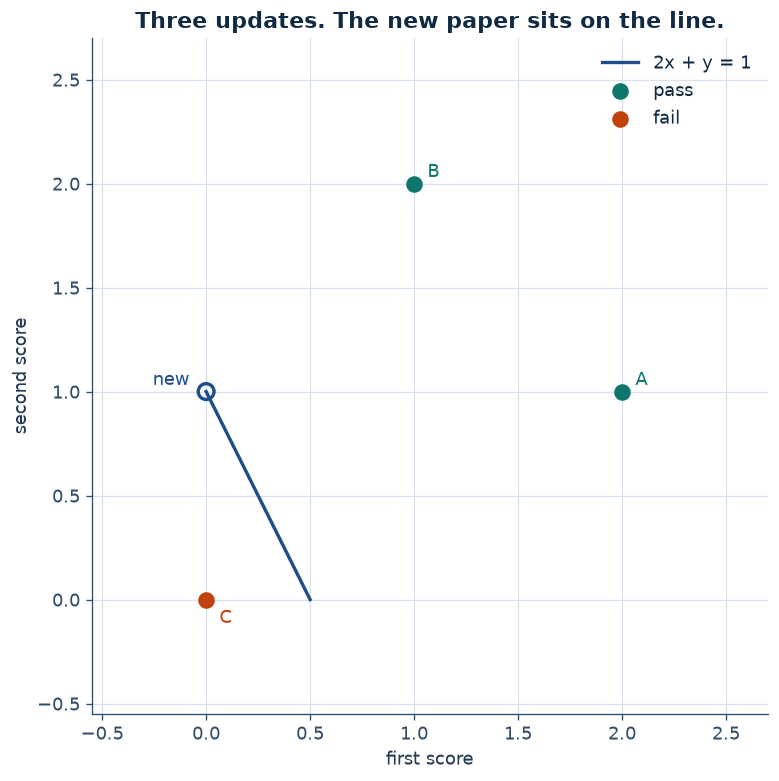

In [2]:
import matplotlib.pyplot as plt

# Pass is green, fail is clay, and a learned line is blue.
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"

# The learned line 2x + y = 1. The unseen paper (0, 1) is the open circle on that line.
fig, ax = plt.subplots(figsize=(7.2, 6.4), constrained_layout=True)
ax.plot([0, 0.5], [1, 0], color=BLUE, linewidth=2, label="2x + y = 1")
ax.scatter([2, 1], [1, 2], s=80, color=GREEN, zorder=3, label="pass")
ax.scatter([0], [0], s=80, color=CLAY, zorder=3, label="fail")
ax.scatter([0], [1], s=90, facecolors="none", edgecolors=BLUE, linewidths=2, zorder=4)
ax.annotate("A", (2, 1), textcoords="offset points", xytext=(8, 4), color=GREEN)
ax.annotate("B", (1, 2), textcoords="offset points", xytext=(8, 4), color=GREEN)
ax.annotate("C", (0, 0), textcoords="offset points", xytext=(8, -14), color=CLAY)
ax.annotate("new", (0, 1), textcoords="offset points", xytext=(-32, 4), color=BLUE)
ax.set_xlim(-0.55, 2.7)
ax.set_ylim(-0.55, 2.7)
ax.set_aspect("equal")
ax.set_xlabel("first score")
ax.set_ylabel("second score")
ax.set_title("Three updates. The new paper sits on the line.")
ax.legend(frameon=False, loc="upper right")


## Pitfall — Do not read this line as the widest street

Training mistakes are zero on A, B, and C. That fact does not select $(2, 1, -1)$ over $(1, 1, -3/2)$. The second of those was never a step in this walk.


In [3]:
# The wider line is a different weight vector, and every training margin is 3/2.
from fractions import Fraction

papers = [((2, 1), 1), ((1, 2), 1), ((0, 0), -1)]
weights = (Fraction(1), Fraction(1), Fraction(-3, 2))
margins = [
    label * (weights[0] * x1 + weights[1] * x2 + weights[2]) for (x1, x2), label in papers
]
print(margins)
assert margins == [Fraction(3, 2), Fraction(3, 2), Fraction(3, 2)]


[Fraction(3, 2), Fraction(3, 2), Fraction(3, 2)]


## Summary

A perceptron is a score, a sign, and an update that adds $y\varphi$ whenever the margin is not positive. On these three papers the update runs three times and stops at $2x_1 + x_2 - 1$. The margin of the point you touch grows by the square of its augmented length. A separator cannot produce infinitely many such touches: on the one-measurement line the ceiling was $10$ and the walk used $5$. The line you reach depends on the order, it need not be the widest, and a loss of zero is not by itself a reason to stop. When a later paper makes every line imperfect, the pocket keeps the best mistake count the walk has actually seen.
